In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold


## Dataset summary

In [48]:
df = pd.read_csv('../data/processed/final_genomics_train_data.csv')

In [49]:
df.shape

(549, 15458)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Columns: 15458 entries, Genotype to DON
dtypes: float64(14925), int64(532), str(1)
memory usage: 64.8 MB


## Missing Values

In [51]:
miss_count=df.isna().sum()
type(miss_count)

miss_count[miss_count>0]

Series([], dtype: int64)

## Duplicated Values

In [52]:
duplicate = df.duplicated()
duplicate.sum()
df[duplicate]

,Genotype,S1A_687822,S1A_1195489,S1A_1234081,S1A_4781815,S1A_4929734,S1A_5190325,S1A_5548635,S1A_5548650,S1A_5857413,...,SUNKNOWN_336365,SUNKNOWN_336436,SUNKNOWN_336436.1,SUNKNOWN_339127,SUNKNOWN_343096,SUNKNOWN_349202,SUNKNOWN_349202.1,SUNKNOWN_349202.2,SUNKNOWN_349202.3,DON


## Target Distribution

In [53]:
y = df["DON"]
y.shape

(549,)

In [54]:
np.unique(y)

array([ 3.12608077,  5.27608077,  5.57608077,  5.62608077,  5.97608077,
        6.07608077,  6.57391923,  6.62608077,  6.72608077,  6.82608077,
        7.27608077,  7.47391923,  7.62608077,  7.77608077,  7.82608077,
        8.07391923,  8.32608077,  8.42608077,  8.67608077,  8.82391923,
        8.92608077,  8.97608077,  9.02608077,  9.27391923,  9.27608077,
        9.32608077,  9.47391923,  9.49130641,  9.52391923,  9.72608077,
        9.82608077,  9.97608077, 10.07391923, 10.12391923, 10.32391923,
       10.37391923, 10.42391923, 10.57391923, 10.72391923, 10.82463974,
       10.82608077, 10.92391923, 11.17391923, 11.32608077, 11.37608077,
       11.42608077, 11.52391923, 11.52608077, 11.57608077, 11.62608077,
       11.72391923, 11.76521615, 11.77608077, 11.87391923, 11.92608077,
       12.02391923, 12.12391923, 12.17608077, 12.22608077, 12.32608077,
       12.45797308, 12.49130641, 12.52608077, 12.57391923, 12.62608077,
       12.67391923, 12.82608077, 12.97391923, 13.02391923, 13.12

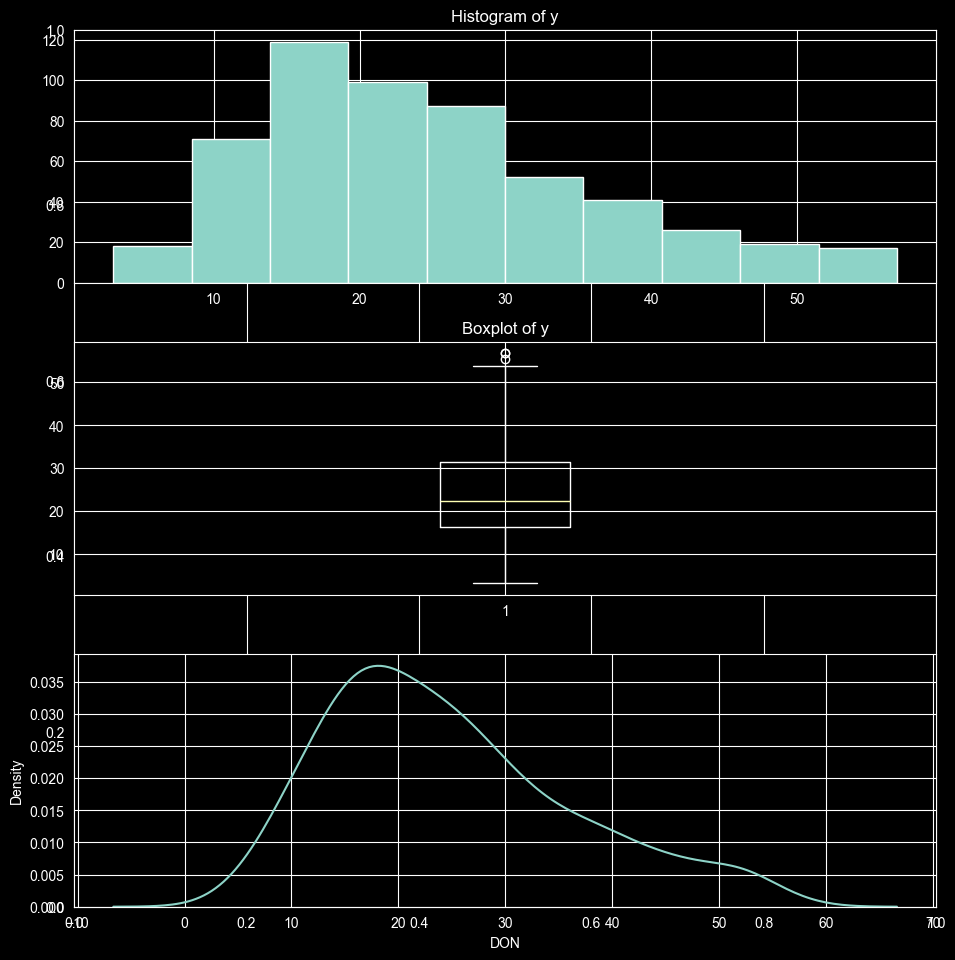

0.7115199321300033


In [55]:
plt.subplots(figsize=(10,10))
plt.subplot(3,1,1)
plt.hist(y,bins=10)
plt.title('Histogram of y')

plt.subplot(3,1,2)
plt.boxplot(y)
plt.title('Boxplot of y')

plt.subplot(3,1,3)
sns.kdeplot(y)


plt.tight_layout()
plt.show()
print(y.skew())

In [56]:
#0.7115199321300033
#Right skewed most data are in the left but some big data are in right

## Outlier Detection

In [97]:
#Outliers
q1 = y.quantile(0.25)
q3 = y.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr


outliers = y[(y < lower_bound) | (y > upper_bound)]

outlier_count = len(outliers)
outlier_percentage = (outlier_count / len(y)) * 100

print(f'Outlier count: {outlier_count}')
print(f'Outlier percentage: {outlier_percentage:.2f}%')

Outlier count: 3
Outlier percentage: 0.55%


In [98]:
print(outliers)

60     56.826081
185    56.776081
208    55.576081
Name: DON, dtype: float64


## Zero Variance Features

Zero-Variance Features: Features that contain the exact same value across all samples, providing zero information or variability for the model.

In [99]:
# روش درست (بدون inplace):
genotypes = df["Genotype"]
y = df["DON"]

# حذف ستون‌ها و ریختن نتیجه در X
X = df.drop(columns=["Genotype", "DON"])


In [100]:
X

,S1A_687822,S1A_1195489,S1A_1234081,S1A_4781815,S1A_4929734,S1A_5190325,S1A_5548635,S1A_5548650,S1A_5857413,S1A_6110098,...,SUNKNOWN_323958,SUNKNOWN_336365,SUNKNOWN_336436,SUNKNOWN_336436.1,SUNKNOWN_339127,SUNKNOWN_343096,SUNKNOWN_349202,SUNKNOWN_349202.1,SUNKNOWN_349202.2,SUNKNOWN_349202.3
0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0
1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,1.0,1.0,0,1.0,1.0,1.0,1.0
2,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,1.0,-1.0,1,1.0,1.0,1.0,1.0
3,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,1,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0
4,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,1,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,1,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,...,1,1.0,1.0,1.0,-1.0,1,1.0,1.0,1.0,0.0
545,1,1.0,1.0,1.0,-1.0,1.0,1.0,0.0,1.0,1.0,...,1,0.0,1.0,0.0,1.0,-1,0.0,1.0,-1.0,1.0
546,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0
547,1,-1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,-1.0,1.0,1,1.0,1.0,1.0,1.0


In [101]:
#np.where(X.columns[X.std()==0])
trash_features = X.columns[X.std()==0]
X_cleaned = X.drop(columns=trash_features)

In [102]:
X_cleaned.shape

(549, 15456)

In [103]:
#from sklearn.feature_selection import VarianceThreshold
#selector = VarianceThreshold(threshold=0.0)

#X_cleaned  = selector.fit_transform(X)
#X_cleaned.shape

## VarianceThreshold

Low-Variance Features: Features that show very little variation or change across samples, carrying minimal useful signal for machine learning models.

In [112]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# ۱. اعمال فیلتر واریانس
selector2 = VarianceThreshold(threshold=0.01)
X_array = selector2.fit_transform(X_cleaned)

# ۲. برگرداندن به فرمت DataFrame به همراه نام ستون‌های اصلی
X_cleaned2 = pd.DataFrame(
    X_array,
    index=X_cleaned.index,
    columns=X_cleaned.columns[selector2.get_support()]
)

# ۳. بررسی ابعاد جدید
print(X_cleaned2.shape)

(549, 15448)


In [113]:
dropped_features = X_cleaned.columns[~selector2.get_support()]
dropped_features

Index(['S1A_17232307', 'S1D_124266806', 'S2D_416035463', 'S3B_152216060',
       'S4A_594468585', 'S5A_266016375', 'S6D_108092891', 'S7B_316531130'],
      dtype='str')

In [114]:
delete_features = X_cleaned.columns[X.var()<=0.01]
X_cleaned2 = X_cleaned.drop(columns=delete_features)
X_cleaned2
delete_features

Index(['S1A_17232307', 'S1D_124266806', 'S2D_416035463', 'S3B_152216060',
       'S4A_594468585', 'S5A_266016375', 'S6D_108092891', 'S7B_316531130'],
      dtype='str')

In [115]:
X_cleaned = X_cleaned2

## Correlation Heatmap

<Axes: >

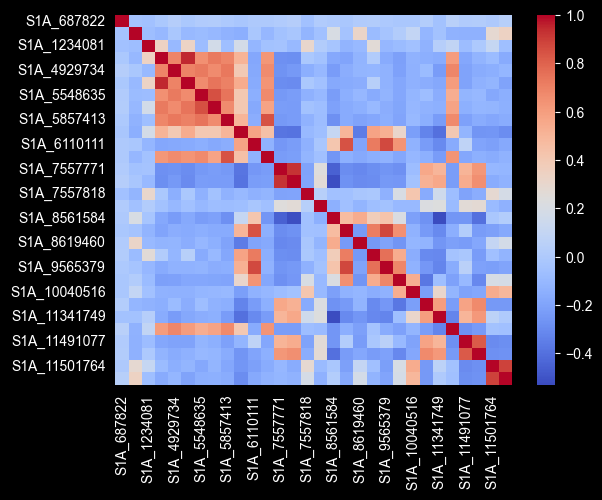

In [116]:
subset_f = X_cleaned.iloc[:,:30]
corr_matrix = subset_f.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm",cbar=True)

<Axes: >

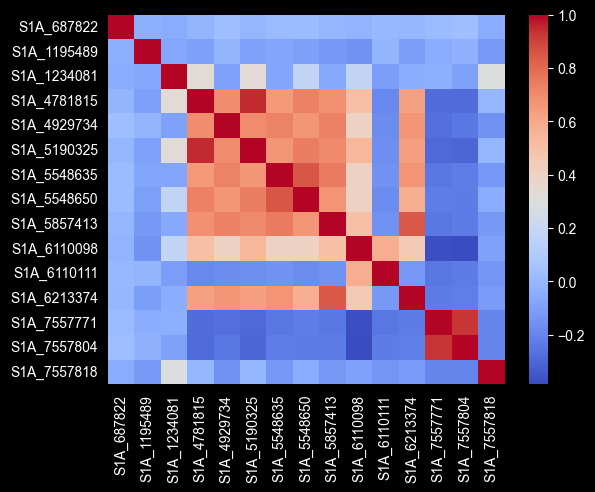

In [121]:
subset = X_cleaned.iloc[:,:15]
corr_matrix = subset.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm",cbar=True)

<Axes: >

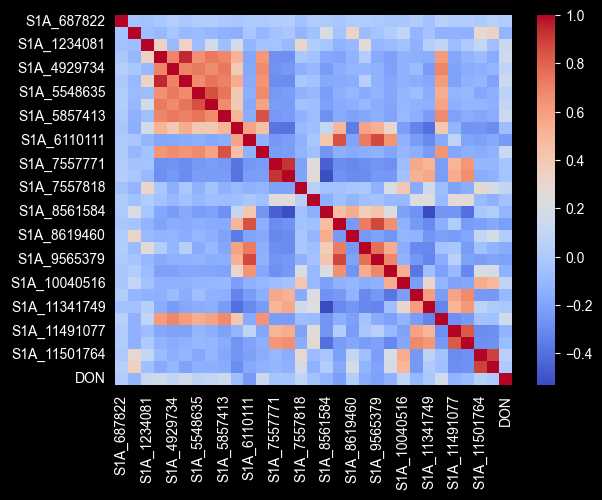

In [158]:
subset_f = X_cleaned.iloc[:, :30].copy()
subset_f['DON'] = y
corr_matrix2 = subset_f.corr()
sns.heatmap(corr_matrix2, annot=False, cmap="coolwarm",cbar=True)

<Axes: >

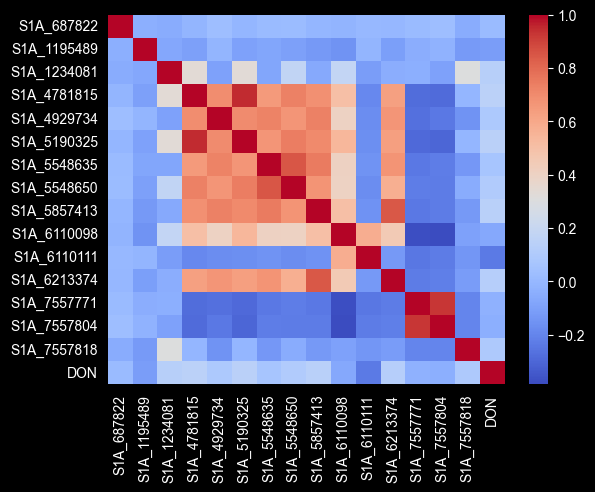

In [124]:
subset2 = X_cleaned.iloc[:,:15]
subset2['DON'] = y
corr_matrix3 = subset2.corr()
sns.heatmap(corr_matrix3, annot=False, cmap="coolwarm",cbar=True)


In [141]:
best =corr_matrix3["DON"]
best=best.drop('DON')
best.sort_values(ascending=False)

S1A_4781815    0.147417
S1A_5190325    0.142396
S1A_5857413    0.138957
S1A_1234081    0.132990
S1A_6213374    0.123980
S1A_5548650    0.103345
S1A_7557818    0.091087
S1A_4929734    0.085287
S1A_5548635    0.064845
S1A_687822     0.010724
S1A_7557771   -0.033686
S1A_7557804   -0.040254
S1A_6110098   -0.071707
S1A_1195489   -0.111690
S1A_6110111   -0.238933
Name: DON, dtype: float64

## Distribution of SNP values

In [143]:
values = X_cleaned.to_numpy().ravel()

In [166]:
total = len(values)

major = np.sum(values == 1)
minor = np.sum(values == -1)
hetero = np.sum(values == 0)

imputed = np.sum(
    (values != 1) &
    (values != -1) &
    (values != 0)
)

print(f"Major allele (1): {major} ({major/total*100:.2f}%)")
print(f"Minor allele (-1): {minor} ({minor/total*100:.2f}%)")
print(f"Heterozygous (0): {hetero} ({hetero/total*100:.2f}%)")
print(f"Imputed values: {imputed} ({imputed/total*100:.2f}%)")

Major allele (1): 6623496 (78.06%)
Minor allele (-1): 1536592 (18.11%)
Heterozygous (0): 322128 (3.80%)
Imputed values: 3128 (0.04%)


The SNP matrix is predominantly composed of homozygous major and minor alleles. Heterozygous genotypes are rare, which is expected because the dataset consists of advanced inbred wheat lines. Approximately 4% of genotype values correspond to imputed missing data.



AttributeError: 'DataFrame' object has no attribute 'ravel'